# 🔬 Skin Cancer Detection with Deep Learning
### BME Science Fair Project — HAM10000 Dataset

**Run cells top to bottom, one at a time.**  
Before starting: `Runtime → Change runtime type → T4 GPU → Save`

## PHASE 1 — Setup & Data Download

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# RECOVERY CELL — run this first every time Colab restarts
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Drive & paths ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, glob, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers

PROJECT_DIR = '/content/drive/MyDrive/skin_cancer_project'
DATASET_DIR = f'{PROJECT_DIR}/ham10000'
MODEL_PATH  = f'{PROJECT_DIR}/best_model.keras'
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

print('✅ Libraries imported')

# ── 2. Class definitions ──────────────────────────────────────────────────────
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
CLASS_DISPLAY = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratosis',
    'vasc':  'Vascular lesion',
    'df':    'Dermatofibroma'
}
CLASS_LABELS = {name: i for i, name in enumerate(CLASS_NAMES)}

print('✅ Class definitions ready')

# ── 3. Load metadata & image paths ───────────────────────────────────────────
metadata = pd.read_csv(f'{DATASET_DIR}/HAM10000_metadata.csv')

path_lookup = {}
for folder in glob.glob(f'{DATASET_DIR}/HAM10000_images*'):
    for fp in glob.glob(f'{folder}/*.jpg'):
        path_lookup[os.path.splitext(os.path.basename(fp))[0]] = fp

metadata['path']  = metadata['image_id'].map(path_lookup)
metadata['label'] = metadata['dx'].map(CLASS_LABELS)
metadata = metadata.dropna(subset=['path']).reset_index(drop=True)

print(f'✅ {len(metadata)} images found')

# ── 4. Splits & class weights ────────────────────────────────────────────────
train_val, test_df = train_test_split(
    metadata, test_size=0.15, random_state=SEED, stratify=metadata['label']
)
train_df, val_df = train_test_split(
    train_val, test_size=0.18, random_state=SEED, stratify=train_val['label']
)

cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label'].values
)
class_weights = {i: w for i, w in enumerate(cw_array)}

print(f'✅ Split — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# ── 5. Dataset pipeline ───────────────────────────────────────────────────────
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label'].values.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_image(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)

print('✅ Datasets ready')

# ── 6. Rebuild model & load saved weights ────────────────────────────────────
base_model = EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = preprocess_input(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)
model   = tf.keras.Model(inputs, outputs)

model.load_weights(MODEL_PATH)
print(f'✅ Model loaded from Drive — ready to continue training')
print(f'\n🟢 ALL DONE — you can now run Phase B (Cell 3.3) directly')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported
✅ Class definitions ready
✅ 10015 images found
✅ Split — Train: 6979 | Val: 1533 | Test: 1503
✅ Datasets ready
✅ Model loaded from Drive — ready to continue training

🟢 ALL DONE — you can now run Phase B (Cell 3.3) directly


In [20]:
# ── Cell 1.1: Mount Google Drive ──────────────────────────────────────────────
# Drive stores your dataset and model so they survive Colab resets
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/skin_cancer_project'
DATASET_DIR = f'{PROJECT_DIR}/ham10000'
os.makedirs(DATASET_DIR, exist_ok=True)

print('✅ Drive mounted')
print('📁 Project folder:', PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
📁 Project folder: /content/drive/MyDrive/skin_cancer_project


In [2]:
# ── Cell 1.2: Upload Kaggle API token ─────────────────────────────────────────
# Go to kaggle.com → Settings → API → Create New Token → upload kaggle.json here
from google.colab import files

print('Select your kaggle.json file...')
files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle token ready')

Select your kaggle.json file...


Saving kaggle.json to kaggle.json
✅ Kaggle token ready


In [6]:
# ── Cell 1.3: Download HAM10000 (skips if already in Drive) ───────────────────
METADATA_PATH = f'{DATASET_DIR}/HAM10000_metadata.csv'

if os.path.exists(METADATA_PATH):
    print('✅ Dataset already in Drive — skipping download!')
else:
    print('⬇️  Downloading HAM10000 (~3 GB) — takes ~5 min...')
    os.system(f'kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {DATASET_DIR}')
    print('📦 Unzipping...')
    os.system(f'unzip -q {DATASET_DIR}/skin-cancer-mnist-ham10000.zip -d {DATASET_DIR}')
    os.system(f'rm {DATASET_DIR}/skin-cancer-mnist-ham10000.zip')
    print('✅ Done!')

✅ Dataset already in Drive — skipping download!


## PHASE 2 — Explore & Preprocess Data

In [21]:
# ── Cell 2.1: Imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2, glob
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

# Constants
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

# The 7 lesion classes in HAM10000
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
CLASS_DISPLAY = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratosis',
    'vasc':  'Vascular lesion',
    'df':    'Dermatofibroma'
}
CLASS_LABELS = {name: i for i, name in enumerate(CLASS_NAMES)}
print('✅ Imports done')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Imports done


In [22]:
# ── Cell 2.2: Load metadata & attach image paths ──────────────────────────────
metadata = pd.read_csv(METADATA_PATH)

# HAM10000 images are split across two folders — find all of them
path_lookup = {}
for folder in glob.glob(f'{DATASET_DIR}/HAM10000_images*'):
    for fp in glob.glob(f'{folder}/*.jpg'):
        path_lookup[os.path.splitext(os.path.basename(fp))[0]] = fp

metadata['path']  = metadata['image_id'].map(path_lookup)
metadata['label'] = metadata['dx'].map(CLASS_LABELS)
metadata = metadata.dropna(subset=['path']).reset_index(drop=True)

print(f'✅ {len(metadata)} images loaded')
print('\nClass distribution:')
print(metadata['dx'].value_counts())

✅ 10015 images loaded

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


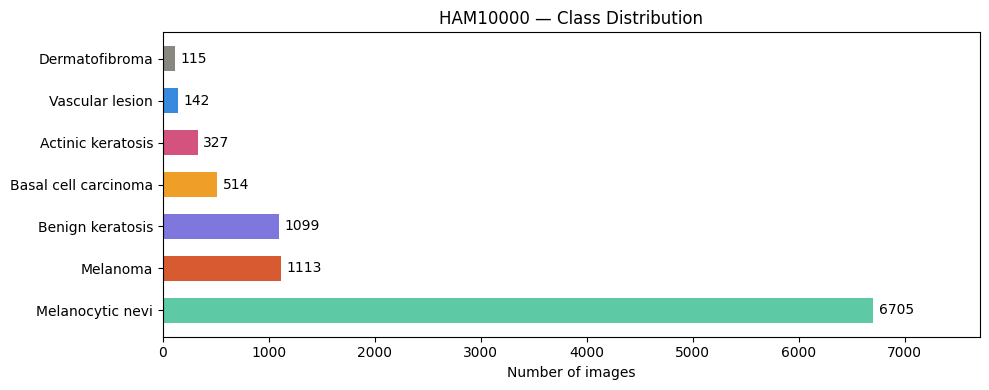

✅ Saved to Drive


In [7]:
# ── Cell 2.3: Plot class distribution (save for poster) ───────────────────────
colors  = ['#5DCAA5','#D85A30','#7F77DD','#EF9F27','#D4537E','#378ADD','#888780']
counts  = [metadata[metadata['dx']==c].shape[0] for c in CLASS_NAMES]
labels  = [CLASS_DISPLAY[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, counts, color=colors, height=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            str(count), va='center', fontsize=10)
ax.set_xlabel('Number of images')
ax.set_title('HAM10000 — Class Distribution')
ax.set_xlim(0, max(counts)*1.15)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to Drive')

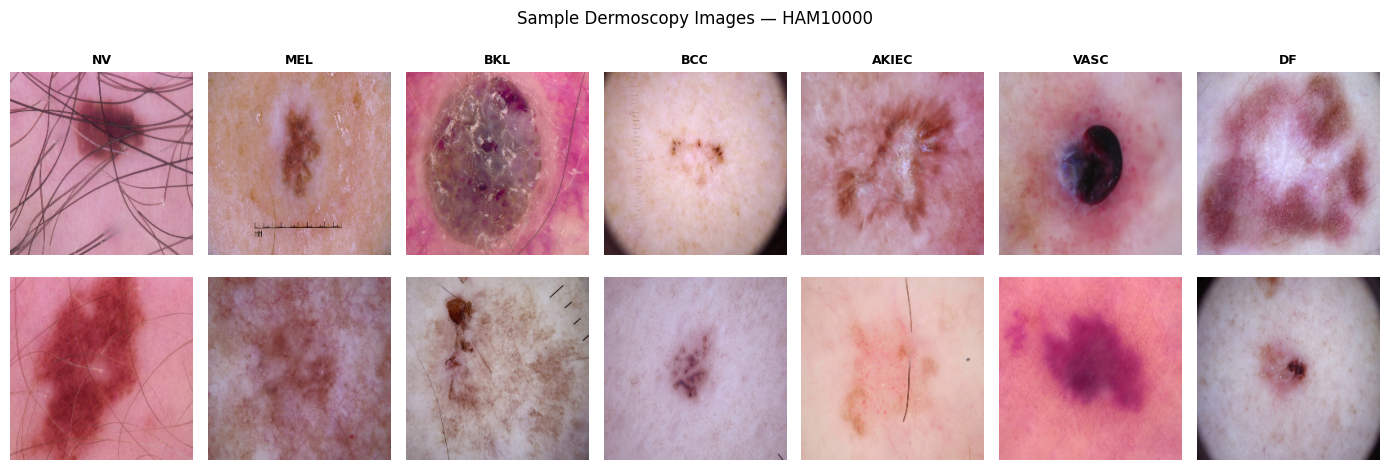

✅ Saved to Drive


In [8]:
# ── Cell 2.4: Show sample images from each class (save for poster) ────────────
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
for col, cls in enumerate(CLASS_NAMES):
    rows = metadata[metadata['dx']==cls].sample(2, random_state=col)
    for row_i, (_, r) in enumerate(rows.iterrows()):
        img = cv2.cvtColor(cv2.imread(r['path']), cv2.COLOR_BGR2RGB)
        axes[row_i, col].imshow(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
        axes[row_i, col].axis('off')
        if row_i == 0:
            axes[row_i, col].set_title(cls.upper(), fontsize=9, fontweight='bold')
plt.suptitle('Sample Dermoscopy Images — HAM10000', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/fig_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to Drive')

In [23]:
# ── Cell 2.5: Train / val / test split ────────────────────────────────────────
# stratify= keeps class proportions equal in every split
train_val, test_df = train_test_split(
    metadata, test_size=0.15, random_state=SEED, stratify=metadata['label']
)
train_df, val_df = train_test_split(
    train_val, test_size=0.18, random_state=SEED, stratify=train_val['label']
)
print(f'Train:      {len(train_df):,} images')
print(f'Validation: {len(val_df):,} images')
print(f'Test:       {len(test_df):,} images')

Train:      6,979 images
Validation: 1,533 images
Test:       1,503 images


In [24]:
# ── Cell 2.6: Compute class weights (fixes imbalance) ─────────────────────────
# Without this the model just predicts 'nv' for everything (it's 67% of data)
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label'].values
)
class_weights = {i: w for i, w in enumerate(cw_array)}
print('Class weights (higher = rarer class, penalised more):')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {CLASS_DISPLAY[n]:25s}: {class_weights[i]:.2f}')

Class weights (higher = rarer class, penalised more):
  Melanocytic nevi         : 0.21
  Melanoma                 : 1.28
  Benign keratosis         : 1.30
  Basal cell carcinoma     : 2.78
  Actinic keratosis        : 4.37
  Vascular lesion          : 10.17
  Dermatofibroma           : 12.46


In [25]:
# ── Cell 2.7: Build tf.data pipeline ─────────────────────────────────────────
# NOTE: pixels stay in 0-255 range — EfficientNetB0 normalises internally

def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)              # keep 0–255
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.clip_by_value(img, 0.0, 255.0) # clamp back to valid range
    return img, label

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label'].values.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_image(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)

# Sanity check
for imgs, lbls in train_ds.take(1):
    print(f'Batch shape : {imgs.shape}')
    print(f'Pixel range : {imgs.numpy().min():.1f} – {imgs.numpy().max():.1f}')
    print(f'Labels      : {sorted(set(lbls.numpy()))}')
print('✅ Pipeline ready')

Batch shape : (32, 224, 224, 3)
Pixel range : 0.0 – 255.0
Labels      : [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
✅ Pipeline ready


## PHASE 3 — Build & Train the Model

In [26]:
# ── Cell 3.1: Build model ─────────────────────────────────────────────────────
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # frozen during head training

# Functional API (more reliable than Sequential for this architecture)
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)              # EfficientNet's own normalisation
x = base_model(x, training=False)         # training=False keeps BN layers frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  (head only)')
print('✅ Model built')

Total params    : 4,058,538
Trainable params: 8,967  (head only)
✅ Model built


In [ ]:
# ── Cell 3.2: Phase A — train classification head only (~8 min) ───────────────
# lr=1e-4 is conservative and stable; avoids the wild swings of higher rates
MODEL_PATH = f'{PROJECT_DIR}/best_model.keras'

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=6,
            restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)
print('\n✅ Phase A done. Best val accuracy:',
      f"{max(history_a.history['val_accuracy']):.1%}")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1350 - loss: 2.0947
Epoch 1: val_accuracy improved from None to 0.37052, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 822s 4s/step - accuracy: 0.2095 - loss: 1.9763 - val_accuracy: 0.3705 - val_loss: 1.7565
Epoch 2/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.3618 - loss: 1.7592
Epoch 2: val_accuracy improved from 0.37052 to 0.50685, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 311ms/step - accuracy: 0.3753 - loss: 1.7863 - val_accuracy: 0.5068 - val_loss: 1.5969
Epoch 3/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4209 - loss: 1.7117
Epoch 3: val_accuracy improved from 0.50685 to 0.5

In [34]:
# ── Cell 3.3: Phase B — fine-tune full model ────────────────────────
# Unfreeze everything and use a very small lr so we don't destroy pretrained weights
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=6,
            restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)
print('\n✅ Phase B done. Best val accuracy:',
      f"{max(history_b.history['val_accuracy']):.1%}")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.5820 - loss: 1.0424
Epoch 1: val_accuracy improved from None to 0.63601, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 222s 640ms/step - accuracy: 0.5929 - loss: 0.9989 - val_accuracy: 0.6360 - val_loss: 1.0853
Epoch 2/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6113 - loss: 0.8950
Epoch 2: val_accuracy improved from 0.63601 to 0.65297, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 75s 342ms/step - accuracy: 0.6210 - loss: 0.9045 - val_accuracy: 0.6530 - val_loss: 1.0273
Epoch 3/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.6339 - loss: 0.8538
Epoch 3: val_accuracy improved from 0.65297 

In [7]:
# ── Cell 3.4: Plot training curves (save for poster) ──────────────────────────
acc   = history_a.history['accuracy']     + history_b.history['accuracy']
val   = history_a.history['val_accuracy'] + history_b.history['val_accuracy']
loss  = history_a.history['loss']         + history_b.history['loss']
vloss = history_a.history['val_loss']     + history_b.history['val_loss']
split = len(history_a.history['accuracy'])
ep    = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, train_vals, val_vals, title, ylabel in [
    (ax1, acc,  val,   'Accuracy', 'Accuracy'),
    (ax2, loss, vloss, 'Loss',     'Loss')
]:
    ax.plot(ep, train_vals, color='#1D9E75', label='Train')
    ax.plot(ep, val_vals,   color='#7F77DD', label='Validation')
    ax.axvline(split, color='#D85A30', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/fig_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to Drive')

NameError: name 'history_a' is not defined

## PHASE 4 — Evaluate & Explain

In [8]:
# ── Cell 4.1: Test set evaluation ─────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Load best saved model
model = tf.keras.models.load_model(MODEL_PATH)

y_true, y_pred_probs = [], []
for imgs, lbls in test_ds:
    y_pred_probs.extend(model.predict(imgs, verbose=0))
    y_true.extend(lbls.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

accuracy = np.mean(y_pred == y_true)
y_bin    = label_binarize(y_true, classes=list(range(7)))
auc      = roc_auc_score(y_bin, y_pred_probs, multi_class='ovr', average='macro')

print(f'Test Accuracy : {accuracy:.1%}')
print(f'AUC-ROC (macro): {auc:.4f}')
print()
print(classification_report(
    y_true, y_pred,
    target_names=[CLASS_DISPLAY[c] for c in CLASS_NAMES]
))

Test Accuracy : 76.4%
AUC-ROC (macro): 0.9610

                      precision    recall  f1-score   support

    Melanocytic nevi       0.95      0.78      0.86      1006
            Melanoma       0.43      0.70      0.54       167
    Benign keratosis       0.62      0.68      0.65       165
Basal cell carcinoma       0.60      0.84      0.70        77
   Actinic keratosis       0.67      0.80      0.73        49
     Vascular lesion       0.62      0.91      0.74        22
      Dermatofibroma       0.40      0.82      0.54        17

            accuracy                           0.76      1503
           macro avg       0.61      0.79      0.68      1503
        weighted avg       0.82      0.76      0.78      1503



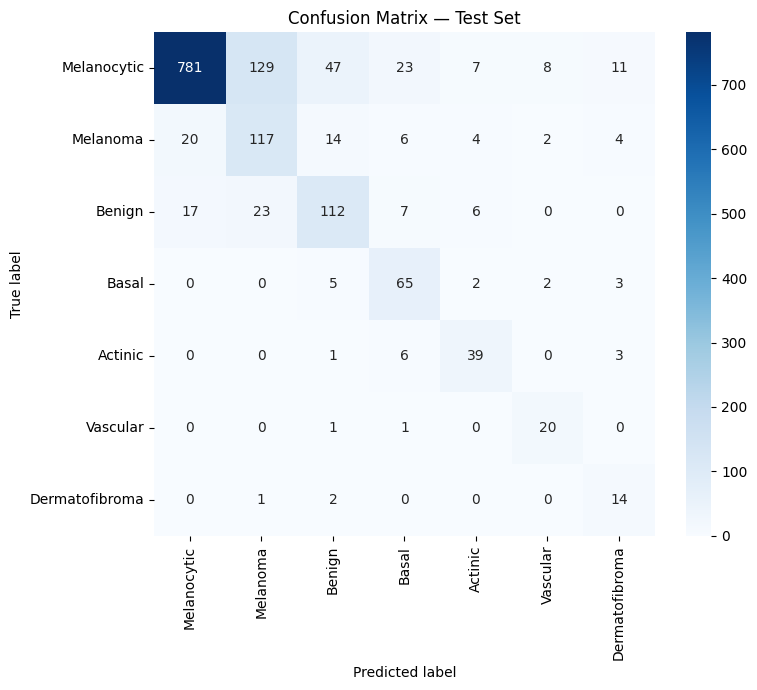

✅ Saved to Drive


In [9]:
# ── Cell 4.2: Confusion matrix (save for poster) ──────────────────────────────
cm = confusion_matrix(y_true, y_pred)
short = [CLASS_DISPLAY[c].split()[0] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax)
ax.set_title('Confusion Matrix — Test Set')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to Drive')

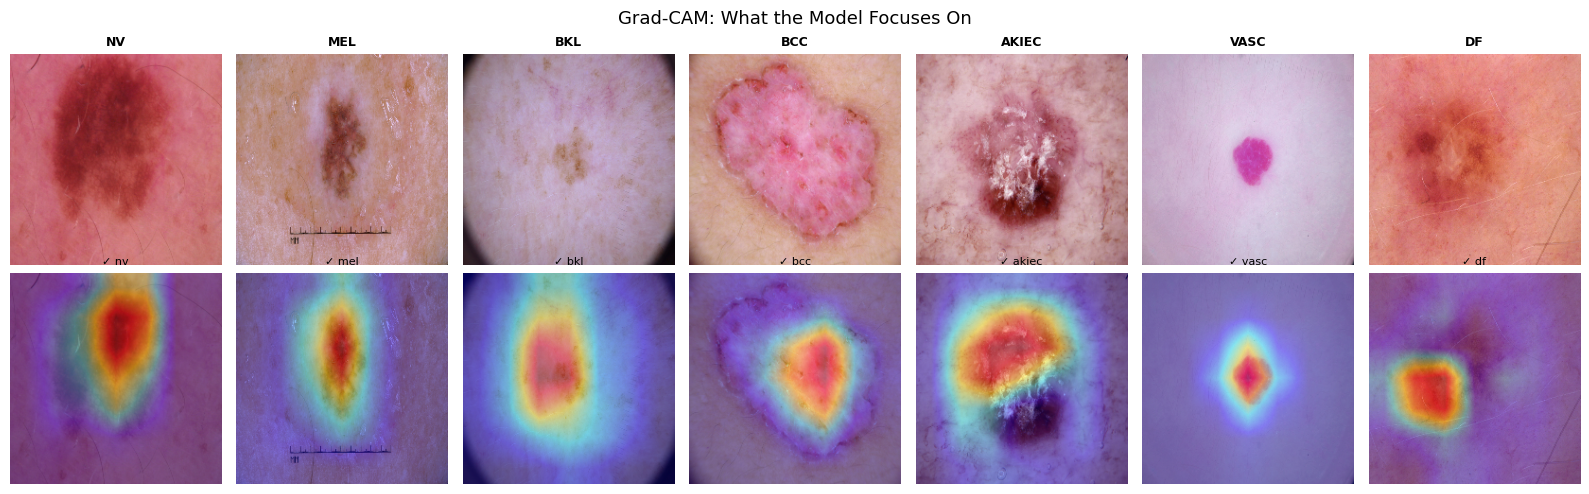

In [16]:
def make_gradcam(model, img_array):
    efficientnet = model.get_layer('efficientnetb0')

    inner_model = tf.keras.Model(
        inputs=efficientnet.inputs,
        outputs=[
            efficientnet.get_layer('top_conv').output,
            efficientnet.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, efficientnet_out = inner_model(img_array)
        tape.watch(conv_outputs)

        x = model.get_layer('global_average_pooling2d_3')(efficientnet_out)
        x = model.get_layer('dropout_3')(x, training=False)
        predictions = model.get_layer('dense_3')(x)

        pred_class = tf.argmax(predictions[0])
        loss = predictions[:, pred_class]

    grads   = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam     = cam / (cam.max() + 1e-8)
    cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return cam, int(pred_class.numpy())

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return (original_img * (1 - alpha) + heatmap_color * alpha).astype(np.uint8)

# Plot
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
fig.suptitle('Grad-CAM: What the Model Focuses On', fontsize=13)

for col, cls in enumerate(CLASS_NAMES):
    sample = metadata[metadata['dx'] == cls].sample(1, random_state=1).iloc[0]
    orig = cv2.cvtColor(cv2.imread(sample['path']), cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    img_tensor = tf.expand_dims(tf.cast(orig, tf.float32), 0)

    axes[0, col].imshow(orig)
    axes[0, col].axis('off')
    axes[0, col].set_title(cls.upper(), fontsize=9, fontweight='bold')

    try:
        cam, pred_idx = make_gradcam(model, img_tensor)
        overlay = overlay_heatmap(orig, cam)
        axes[1, col].imshow(overlay)
        correct = '✓' if CLASS_NAMES[pred_idx] == cls else '✗'
        axes[1, col].set_title(f'{correct} {CLASS_NAMES[pred_idx]}', fontsize=8)
    except Exception as e:
        axes[1, col].text(0.5, 0.5, 'N/A', ha='center', va='center')
        print(f'{cls} error: {e}')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/fig_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## PHASE 5 — Live Demo

In [11]:
# ── Cell 5.1: Interactive demo — upload any image and get a prediction ────────
# Use this live at your science fair!
from google.colab import files
import IPython.display as display

# Load the best saved model
model = tf.keras.models.load_model(MODEL_PATH)

print('Upload a dermoscopy image (JPG/PNG):')
uploaded = files.upload()

for fname in uploaded:
    # Load and preprocess
    img_raw = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_tensor = tf.expand_dims(tf.cast(img_res, tf.float32), 0)

    # Predict
    probs    = model.predict(img_tensor, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_cls = CLASS_NAMES[pred_idx]
    pred_lbl = CLASS_DISPLAY[pred_cls]
    confidence = probs[pred_idx]

    # Grad-CAM
    cam, _ = make_gradcam(model, img_tensor)
    overlay = overlay_heatmap(img_res, cam)

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_res);  axes[0].set_title('Input image');  axes[0].axis('off')
    axes[1].imshow(overlay);  axes[1].set_title('Grad-CAM');     axes[1].axis('off')

    # Probability bar chart
    colors_bar = ['#D85A30' if i==pred_idx else '#AAAAAA' for i in range(7)]
    axes[2].barh([CLASS_DISPLAY[c] for c in CLASS_NAMES], probs, color=colors_bar)
    axes[2].set_xlim(0, 1)
    axes[2].set_title('Class probabilities')
    axes[2].set_xlabel('Confidence')

    plt.suptitle(f'Prediction: {pred_lbl}  ({confidence:.1%} confidence)',
                 fontsize=13, fontweight='bold', color='#D85A30')
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/demo_result.png', dpi=150, bbox_inches='tight')
    plt.show()

Upload a dermoscopy image (JPG/PNG):


In [1]:
import os
print(os.path.exists('/content/drive/MyDrive/skin_cancer_project/best_model.keras'))

True


In [11]:
# Load best saved model
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/skin_cancer_project/best_model.keras'
)
print('Loaded! Resuming from epoch 12...')

# Continue Phase A from where it left off
history_a_resumed = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    initial_epoch=12,         # starts at epoch 13, skips 1–12
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/skin_cancer_project/best_model.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=6,
            restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)

Loaded! Resuming from epoch 12...
Epoch 13/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.5744 - loss: 1.2687
Epoch 13: val_accuracy improved from None to 0.58382, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 13: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 164s 559ms/step - accuracy: 0.5730 - loss: 1.2450 - val_accuracy: 0.5838 - val_loss: 1.2095
Epoch 14/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5753 - loss: 1.1870
Epoch 14: val_accuracy improved from 0.58382 to 0.59100, saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras

Epoch 14: finished saving model to /content/drive/MyDrive/skin_cancer_project/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 61s 276ms/step - accuracy: 0.5713 - loss: 1.2176 - val_accuracy: 0.5910 - val_loss: 1.1776
Epoch 15/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5641 - loss: 1.2248
Epo

In [29]:
MODEL_PATH = '/content/drive/MyDrive/skin_cancer_project/best_model.keras'
model.load_weights(MODEL_PATH)
print('Weights loaded!')

Weights loaded!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
# Check 1: does the file exist?
print('Model file exists:', os.path.exists(MODEL_PATH))
print('Model path:', MODEL_PATH)

# Check 2: what's the current val accuracy on one batch?
results = model.evaluate(val_ds, verbose=0)
print(f'Current val accuracy: {results[1]:.1%}')

Model file exists: True
Model path: /content/drive/MyDrive/skin_cancer_project/best_model.keras
Current val accuracy: 60.1%


In [12]:
model = tf.keras.models.load_model(MODEL_PATH)

# Find the last convolutional layer in the model
for layer in reversed(model.layers):
    print(layer.name, layer.__class__.__name__)
    if 'conv' in layer.name.lower():
        print(f'\n✅ Use this layer name: "{layer.name}"')
        break

dense_3 Dense
dropout_3 Dropout
global_average_pooling2d_3 GlobalAveragePooling2D
efficientnetb0 Functional
input_layer_7 InputLayer


In [13]:
# Look inside the EfficientNetB0 layer for the last conv layer
efficientnet_layer = model.get_layer('efficientnetb0')

for layer in reversed(efficientnet_layer.layers):
    print(layer.name, layer.__class__.__name__)
    if 'conv' in layer.name.lower():
        print(f'\n✅ Use this layer name: "{layer.name}"')
        break

top_activation Activation
top_bn BatchNormalization
top_conv Conv2D

✅ Use this layer name: "top_conv"
